<a href="https://colab.research.google.com/github/prathyusha2020/AAIS_322-Natural-Language-Processing-and-Computer-Vision/blob/main/Module4_Session1_Object_Detection_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4 · Session 1 — Object Detection Building Blocks

**AAIS-322 · Designing an Object Detection System**

Four small pieces of code. Every one of them comes back in Sessions 2, 3 and 4:

| Piece | Why it matters later |
|---|---|
| **Box formats** | YOLO wants normalized `(cx, cy, w, h)`. COCO gives you `(x, y, w, h)`. Getting this wrong is the #1 silent bug in Session 3. |
| **IoU** | The ruler for "is this prediction correct?" Underneath NMS *and* mAP. |
| **NMS** | Turns 40 overlapping boxes into 2. Every detector you run has this inside it. |
| **`draw_boxes`** | You'll use it every week to see what your model actually did. |

There is **no model and no download** in this notebook — we build the scene ourselves so
nothing can fail in class. We add the model in Session 3.

---
## 1 · Setup and a scene to work on

An image is just a NumPy array of shape `(height, width, 3)`. We'll build a tiny
"street scene" by filling in blocks of pixels — that way we know the exact ground truth.

image array shape: (260, 400, 3)  -> height 260 width 400


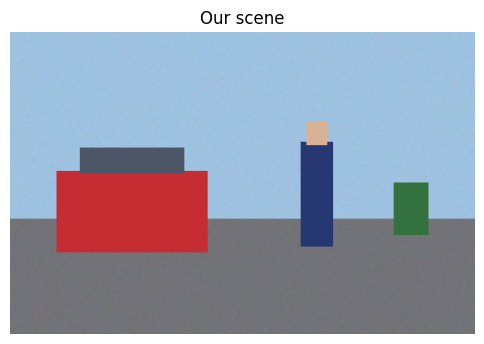

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def make_scene(width=400, height=260, seed=0):
    rng = np.random.default_rng(seed)
    img = np.zeros((height, width, 3))
    img[:, :] = [0.62, 0.76, 0.88]                    # sky
    img[int(height * 0.62):, :] = [0.45, 0.45, 0.47]  # road
    img += rng.normal(0, 0.012, img.shape)            # a little texture

    def block(x1, y1, x2, y2, color):
        img[int(y1):int(y2), int(x1):int(x2)] = color

    block(40, 120, 170, 190, [0.78, 0.18, 0.20])      # car body
    block(60, 100, 150, 122, [0.30, 0.34, 0.40])      # car roof
    block(250, 95, 278, 185, [0.15, 0.22, 0.45])      # person body
    block(255, 78, 273,  98, [0.85, 0.70, 0.58])      # person head
    block(330, 130, 360, 175, [0.20, 0.45, 0.25])     # bush
    return np.clip(img, 0, 1)

img = make_scene()
H, W = img.shape[:2]
print("image array shape:", img.shape, " -> height", H, "width", W)

plt.figure(figsize=(6, 4))
plt.imshow(img); plt.axis("off"); plt.title("Our scene")
plt.show()

> **Note the axis order.** `img.shape` is `(height, width, channels)` — rows first.
> But boxes are written `(x, y, ...)` — columns first. Row/column and x/y are swapped,
> and the origin `(0, 0)` is the **top-left**, with `y` increasing *downward*.
> Nearly every "my boxes are in the wrong place" bug traces back to one of those two facts.

---
## 2 · A box is four numbers — but *which* four?

Three formats you will meet. Same box, three encodings:

| Format | Numbers | Used by |
|---|---|---|
| **Corners** (`xyxy`) | `x_min, y_min, x_max, y_max` | Pascal VOC, torchvision, most drawing code |
| **Corner + size** (`xywh`) | `x_min, y_min, width, height` | **COCO** annotations |
| **YOLO** | `cx, cy, w, h` — **normalized 0–1** | YOLO label `.txt` files (Session 3) |

Normalization is why YOLO labels survive resizing: the numbers are fractions of the
image, so they stay correct whether the image is 400px or 4000px wide.

In [2]:
def xyxy_to_xywh(b):
    x1, y1, x2, y2 = b
    return (x1, y1, x2 - x1, y2 - y1)

def xywh_to_xyxy(b):
    x, y, w, h = b
    return (x, y, x + w, y + h)

def xyxy_to_yolo(b, img_w, img_h):
    x1, y1, x2, y2 = b
    return (((x1 + x2) / 2) / img_w,      # cx
            ((y1 + y2) / 2) / img_h,      # cy
            (x2 - x1) / img_w,            # w
            (y2 - y1) / img_h)            # h

def yolo_to_xyxy(b, img_w, img_h):
    cx, cy, w, h = b
    cx, w = cx * img_w, w * img_w
    cy, h = cy * img_h, h * img_h
    return (cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2)


car = (40, 100, 170, 190)          # our car, in corner format

print("xyxy (corners) :", car)
print("xywh (COCO)    :", xyxy_to_xywh(car))
print("yolo (norm)    :", tuple(round(v, 4) for v in xyxy_to_yolo(car, W, H)))
print()
print("round trip back:", tuple(round(v, 1) for v in yolo_to_xyxy(xyxy_to_yolo(car, W, H), W, H)))

xyxy (corners) : (40, 100, 170, 190)
xywh (COCO)    : (40, 100, 130, 90)
yolo (norm)    : (0.2625, 0.5577, 0.325, 0.3462)

round trip back: (40.0, 100.0, 170.0, 190.0)


**Try it:** what happens if you feed `xywh` numbers into a function expecting `xyxy`?
Nothing crashes. You just get a box in the wrong place — which is exactly why this bug
is so hard to find. Test the round trip every time you write a converter.

---
## 3 · Seeing the boxes

One helper we reuse all module. A detection is really a **triple**:
`box` + `class label` + `confidence score`.

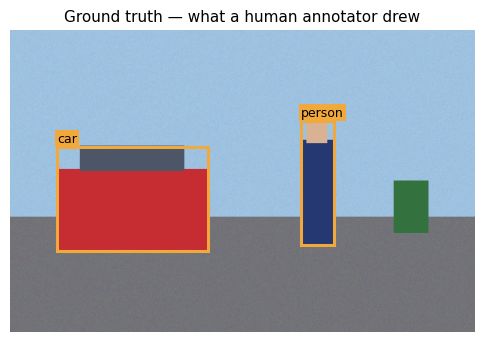

In [12]:
def draw_boxes(img, boxes, labels=None, scores=None, color="#F2A93B",
               ax=None, title=None, linewidth=2.2):
    '''Draw (x1, y1, x2, y2) boxes on an image.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img)
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        c = color[i] if isinstance(color, (list, tuple)) else color
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor=c, linewidth=linewidth))
        text = str(labels[i]) if labels is not None else ""
        if scores is not None:
            text = f"{text} {scores[i]:.2f}".strip()
        if text:
            ax.text(x1, y1 - 4, text, fontsize=9, color="black",
                    bbox=dict(facecolor=c, edgecolor="none", pad=1.5))
    ax.set_title(title or "", fontsize=11)
    ax.axis("off")
    return ax


ground_truth = [(40, 100, 170, 190), (250, 78, 278, 185)]
gt_labels    = ["car", "person"]

draw_boxes(img, ground_truth, gt_labels, title="Ground truth — what a human annotator drew")
plt.show()

---
## 4 · IoU — how we grade a box

A predicted box is never pixel-perfect. So how close is close enough?

$$\text{IoU} = \frac{\text{area of overlap}}{\text{area of union}}$$

0 means no overlap, 1 means identical. **This one number is the foundation of everything
else** — the pass/fail rule for a prediction, the duplicate test inside NMS, and the
threshold behind mAP.

In [4]:
def iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # the overlapping rectangle: latest start, earliest end
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)   # max(0,...) => no overlap -> 0

    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union  = area_a + area_b - inter                    # subtract, or overlap counts twice

    return inter / union if union > 0 else 0.0


# sanity checks first — always
print("identical boxes :", iou((0, 0, 10, 10), (0, 0, 10, 10)))
print("no overlap      :", iou((0, 0, 10, 10), (20, 20, 30, 30)))
print("edges touching  :", iou((0, 0, 10, 10), (10, 0, 20, 10)))
print("shifted by half :", round(iou((0, 0, 10, 10), (5, 0, 15, 10)), 4))

identical boxes : 1.0
no overlap      : 0.0
edges touching  : 0.0
shifted by half : 0.3333


Now against a real prediction — a box that is *nearly* the car:

IoU with ground truth = 0.738
Counts as correct at threshold 0.5? True
Counts as correct at threshold 0.75? False


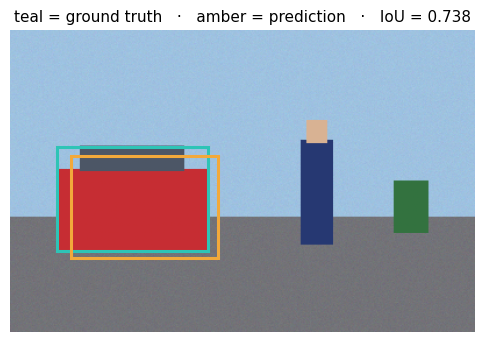

In [5]:
pred_car = (52, 108, 178, 196)      # a plausible model output

score = iou(ground_truth[0], pred_car)
print(f"IoU with ground truth = {score:.3f}")
print("Counts as correct at threshold 0.5?", score >= 0.5)
print("Counts as correct at threshold 0.75?", score >= 0.75)

draw_boxes(img, [ground_truth[0], pred_car],
           color=["#2EC4B6", "#F2A93B"],
           title=f"teal = ground truth   ·   amber = prediction   ·   IoU = {score:.3f}")
plt.show()

> **Discussion.** Nothing in mathematics says 0.5 is the right cutoff — it's a convention
> inherited from the Pascal VOC benchmark. A parking-space counter can live with 0.5.
> A surgical robot cannot. **The threshold is a design decision, not a constant.**

---
## 5 · NMS — from 40 boxes down to 2

Detectors don't produce one box per object. They score thousands of candidate regions,
and every region *near* the car also looks like a car. Raw output is a pile of duplicates:

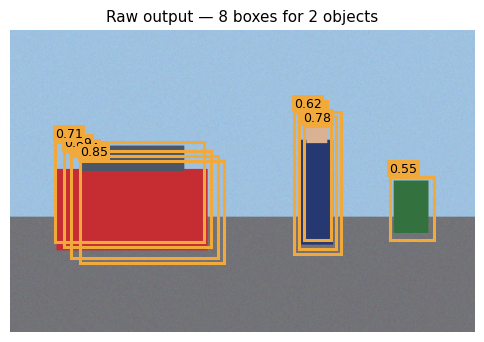

In [6]:
# raw output, as a detector would give it: boxes + scores, duplicates and all
raw_boxes = [(52, 108, 178, 196), (46, 104, 172, 186), (60, 112, 184, 200),
             (38,  96, 166, 182), (248,  74, 280, 188), (252,  82, 276, 180),
             (244,  70, 284, 192), (326, 126, 364, 180)]
raw_scores = [0.94, 0.89, 0.85, 0.71, 0.91, 0.78, 0.62, 0.55]

draw_boxes(img, raw_boxes, scores=raw_scores,
           title=f"Raw output — {len(raw_boxes)} boxes for 2 objects")
plt.show()

kept indices: [0, 4, 7] (8 boxes -> 3)


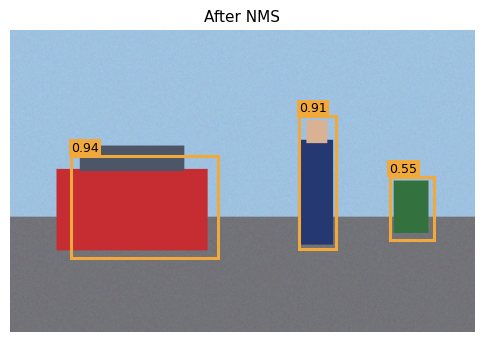

In [14]:
def nms(boxes, scores, iou_threshold=0.6):
    '''Greedy non-maximum suppression. Returns the indices worth keeping.'''
    # 1. rank every box by confidence, highest first
    order = sorted(range(len(boxes)), key=lambda i: scores[i], reverse=True)
    keep = []
    while order:
        best = order.pop(0)          # 2. the most confident box survives
        keep.append(best)
        # 3. discard anything overlapping it too much — same object
        order = [i for i in order if iou(boxes[best], boxes[i]) < iou_threshold]
    return keep                      # 4. repeat with what's left


kept = nms(raw_boxes, raw_scores, iou_threshold=0.5)
print("kept indices:", kept, f"({len(raw_boxes)} boxes -> {len(kept)})")

draw_boxes(img, [raw_boxes[i] for i in kept],
           scores=[raw_scores[i] for i in kept],
           title="After NMS")
plt.show()

### The two knobs

Every detector you ever run exposes these. They are the fastest way to change results
without retraining anything — and the fastest way to fool yourself.

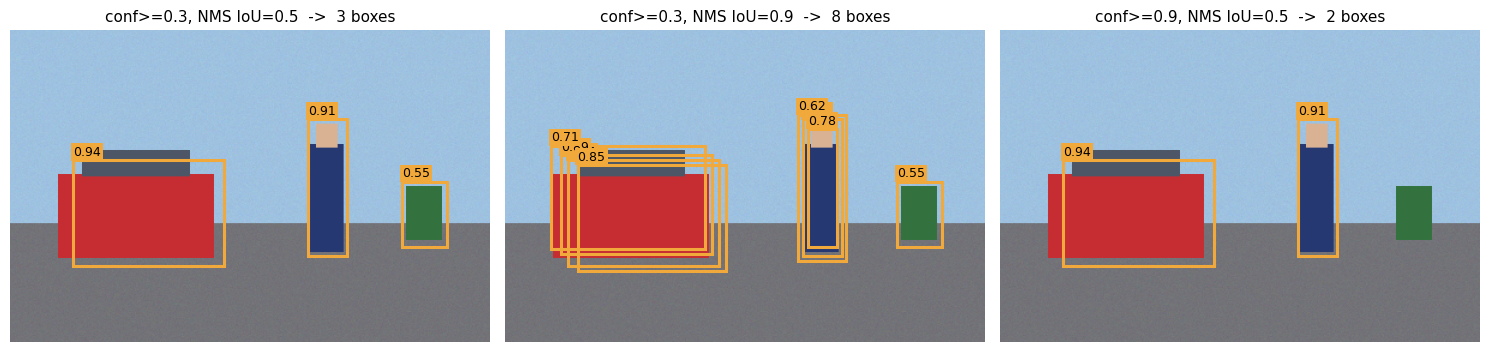

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

for ax, (conf_t, nms_t) in zip(axes, [(0.30, 0.50), (0.30, 0.90), (0.90, 0.50)]):
    idx = [i for i in range(len(raw_boxes)) if raw_scores[i] >= conf_t]
    sub_b = [raw_boxes[i] for i in idx]
    sub_s = [raw_scores[i] for i in idx]
    k = nms(sub_b, sub_s, nms_t)
    draw_boxes(img, [sub_b[i] for i in k], scores=[sub_s[i] for i in k], ax=ax,
               title=f"conf>={conf_t}, NMS IoU={nms_t}  ->  {len(k)} boxes")

plt.tight_layout(); plt.show()

Read the three panels left to right:

1. **Balanced** — two objects, two boxes. What we want.
2. **NMS threshold too high (0.9)** — almost nothing counts as a duplicate, so the pile
   survives. One object gets reported four times.
3. **Confidence threshold too high (0.9)** — the low-scoring boxes are gone, but so is
   the bush and possibly a real object. Fewer false alarms, more misses.

There is no "correct" setting. A self-driving car (Session 2) would rather brake for a
shadow than miss a pedestrian, so it runs a **low** confidence threshold. A system that
auto-issues traffic tickets would run a high one. Same model, opposite tuning.

---
## 6 · Save these for later

We will `import` this file in Sessions 2–4 rather than retyping the functions.

In [9]:
%%writefile detutils.py
# AAIS-322 Module 4 — shared detection helpers
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches

def xyxy_to_xywh(b):
    x1, y1, x2, y2 = b; return (x1, y1, x2 - x1, y2 - y1)

def xywh_to_xyxy(b):
    x, y, w, h = b; return (x, y, x + w, y + h)

def xyxy_to_yolo(b, iw, ih):
    x1, y1, x2, y2 = b
    return (((x1+x2)/2)/iw, ((y1+y2)/2)/ih, (x2-x1)/iw, (y2-y1)/ih)

def yolo_to_xyxy(b, iw, ih):
    cx, cy, w, h = b; cx, w = cx*iw, w*iw; cy, h = cy*ih, h*ih
    return (cx-w/2, cy-h/2, cx+w/2, cy+h/2)

def iou(a, b):
    ax1, ay1, ax2, ay2 = a; bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2-ix1) * max(0.0, iy2-iy1)
    union = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter/union if union > 0 else 0.0

def nms(boxes, scores, iou_threshold=0.5):
    order = sorted(range(len(boxes)), key=lambda i: scores[i], reverse=True)
    keep = []
    while order:
        best = order.pop(0); keep.append(best)
        order = [i for i in order if iou(boxes[best], boxes[i]) < iou_threshold]
    return keep

def draw_boxes(img, boxes, labels=None, scores=None, color="#F2A93B",
               ax=None, title=None, linewidth=2.2):
    if ax is None: _, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img)
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        c = color[i] if isinstance(color, (list, tuple)) else color
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       fill=False, edgecolor=c, linewidth=linewidth))
        t = str(labels[i]) if labels is not None else ""
        if scores is not None: t = f"{t} {scores[i]:.2f}".strip()
        if t: ax.text(x1, y1-4, t, fontsize=9, color="black",
                      bbox=dict(facecolor=c, edgecolor="none", pad=1.5))
    ax.set_title(title or "", fontsize=11); ax.axis("off")
    return ax

Writing detutils.py


In [10]:
from detutils import iou, nms, draw_boxes
print("imported OK — IoU self-test:", iou((0, 0, 10, 10), (5, 0, 15, 10)))

imported OK — IoU self-test: 0.3333333333333333


---
## Recap

| Concept | In one line |
|---|---|
| **Detection** | *what* + *where* + *how many* — the output length varies per image |
| **Box formats** | `xyxy` / `xywh` / normalized YOLO — always test the round trip |
| **IoU** | overlap ÷ union; the ruler for every other metric |
| **NMS** | keep the most confident box, delete its overlapping twins, repeat |
| **The two knobs** | confidence threshold (how sure) vs NMS IoU (how duplicate) |

### Exercises

1. Write `iou_matrix(boxes_a, boxes_b)` returning an array of every pairwise IoU.
2. `nms()` above is *class-agnostic* — it will suppress a person box that overlaps a car
   box. Fix it so suppression only happens **within** a class.
3. Sweep the NMS threshold from 0.1 to 0.9 and plot how many boxes survive.
4. A prediction has IoU 0.62 with the car and 0.00 with the person. Under `mAP@0.5` it
   counts. Under `mAP@0.75` it doesn't. Why does COCO report the harsher number?

### Next session
Object detection in autonomous systems — where these thresholds stop being a tuning
exercise and start being a safety decision.